# wav2vec2 Error Analysis

This notebook analyzes wav2vec2 WER results with focus on:
- SNR vs error
- Overlap ratio vs error (for each SNR)
- Cross analysis between SNR and overlap ratio
- Interpretation tables for actionable insights

In [16]:
import sys
import importlib
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Resolve project root whether notebook cwd is project root or Code/
project_root = Path.cwd().resolve()
if project_root.name == "Code":
    project_root = project_root.parent

code_dir = project_root / "Code"
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

RESULTS_DIR = project_root / "WER_Results_by_Model"
PLOTS_DIR = project_root / "Output" / "plot"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

import stats_utils
importlib.reload(stats_utils)

def save_plot(result, filename):
    fig = result[0] if isinstance(result, tuple) else result
    fig.savefig(PLOTS_DIR / filename, dpi=200, bbox_inches="tight")
    return result

from stats_utils import (
    load_wer_json,
    build_analysis_df,
    get_interpretation_tables,
    plot_snr_vs_error,
    plot_overlap_vs_error_by_snr,
    plot_snr_vs_error_by_overlap,
    plot_cross_heatmaps,
    plot_noise_type_effect,
    plot_error_cdf_by_snr,
    plot_degradation_delta_vs_snr,
    plot_error_variability_by_condition,
    plot_snr_ovr_heatmap
)

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

In [2]:
# Load wav2vec2 evaluation output (3720 clips)
json_path = RESULTS_DIR / "wav2vec2_wer_results.json"
wer_json = load_wer_json(str(json_path))

# Keep all rows for coverage analysis, then subset successful rows for error analysis
df_all = build_analysis_df(wer_json, include_failed=True)
df_success = df_all[df_all["status"] == "success"].copy()

overview = {
    "total_rows": len(df_all),
    "successful_rows": int((df_all["status"] == "success").sum()),
    "failed_rows": int((df_all["status"] != "success").sum()),
    "error_metric_types": df_success["metric_type"].value_counts(dropna=False).to_dict(),
    "snr_values": sorted(df_success["snr_db"].dropna().unique().tolist()),
    "overlap_values": sorted(df_success["overlap_ratio"].dropna().unique().tolist()),
}
overview

{'total_rows': 3720,
 'successful_rows': 3720,
 'failed_rows': 0,
 'error_metric_types': {'wer': 3720},
 'snr_values': [-5.0, 0.0, 7.4],
 'overlap_values': [0.0, 0.14, 0.2, 0.4]}

## Plots

1. SNR vs error (including No noise as a normal SNR category)
2. Overlap ratio vs error for each SNR with overall in the same plot
3. SNR vs error for each overlap ratio with overall in the same plot
4. Cross analysis between SNR and overlap ratio

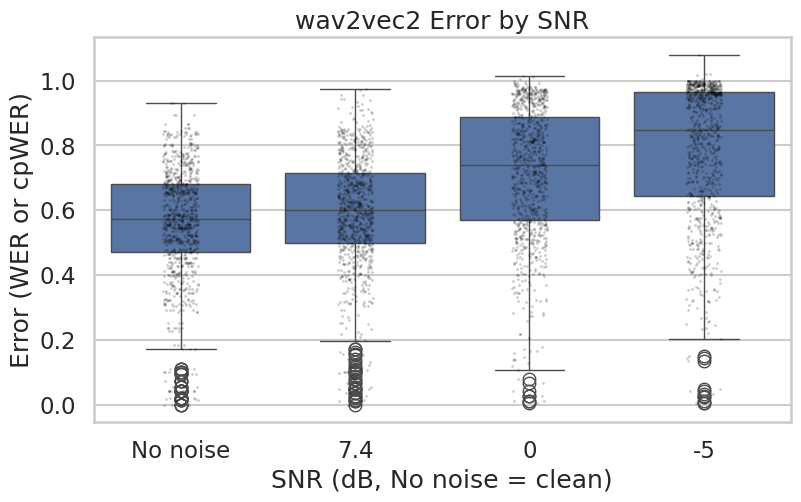

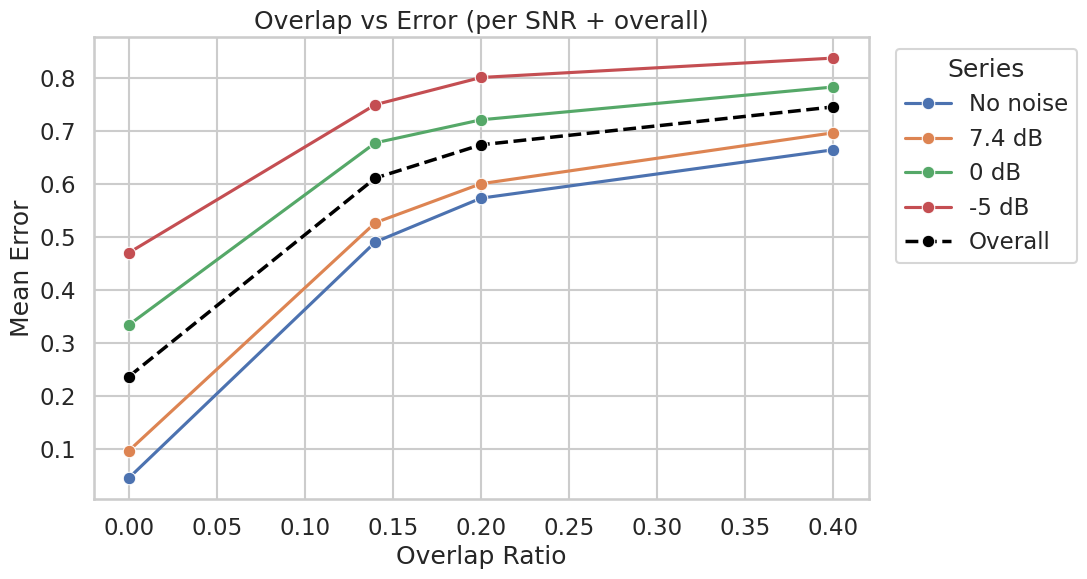

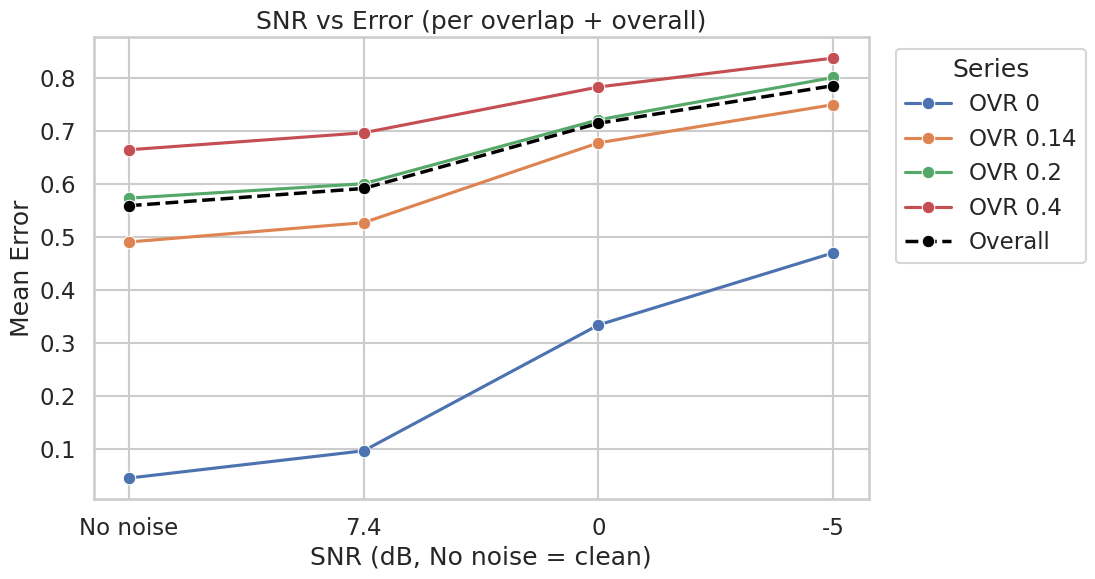

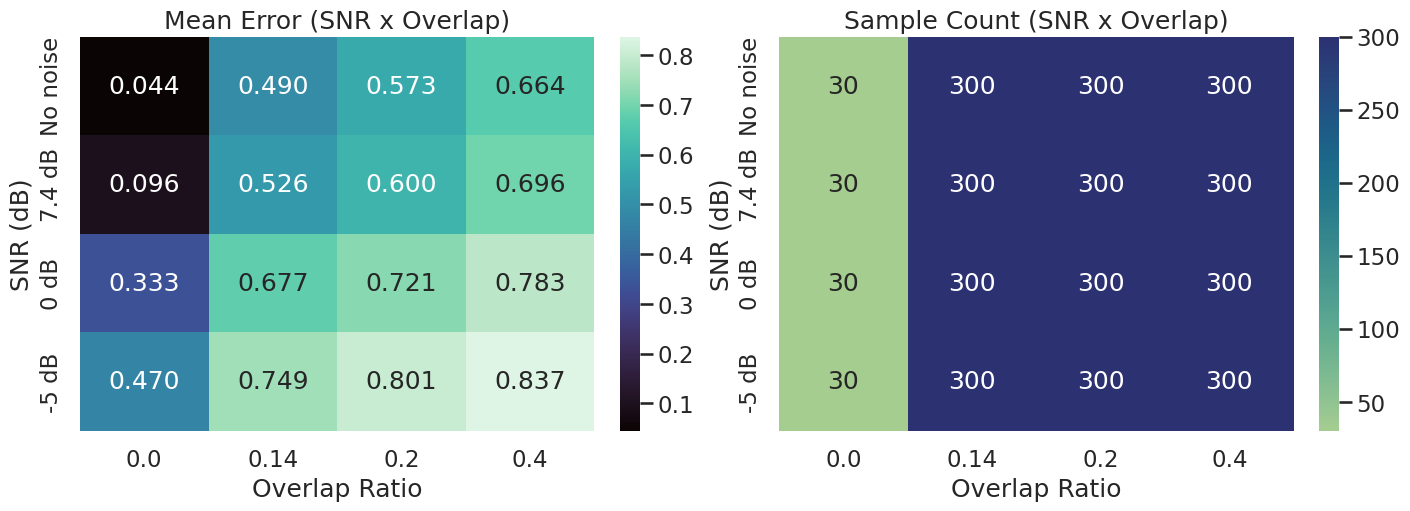

In [3]:
save_plot(plot_snr_vs_error(df_success), "snr_vs_error.png")
plt.show()

save_plot(plot_overlap_vs_error_by_snr(df_success), "overlap_vs_error_by_snr.png")
plt.show()

save_plot(plot_snr_vs_error_by_overlap(df_success), "snr_vs_error_by_overlap.png")
plt.show()

save_plot(plot_cross_heatmaps(df_success), "cross_heatmaps.png")
plt.show()

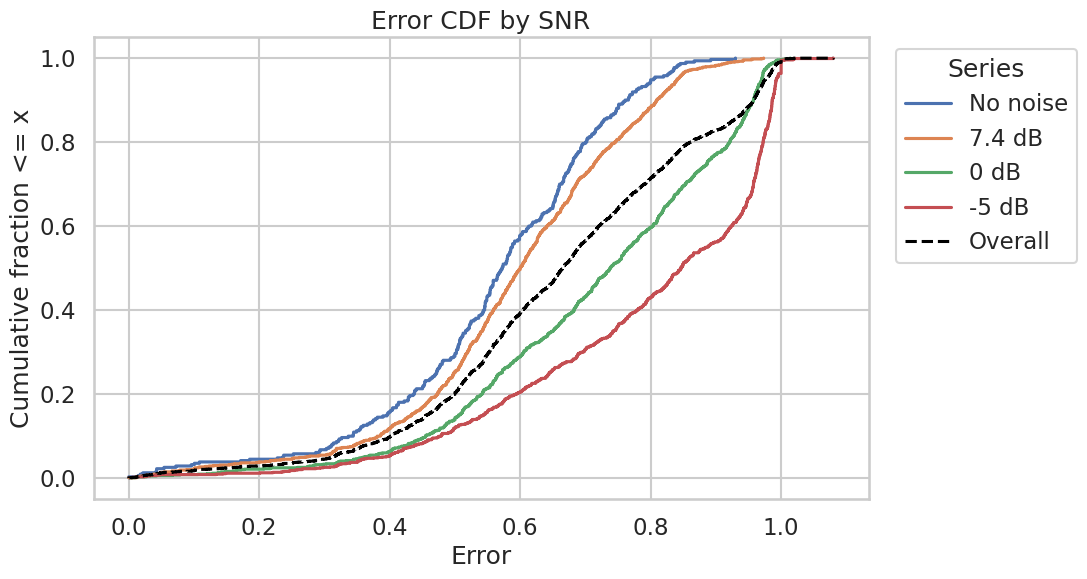

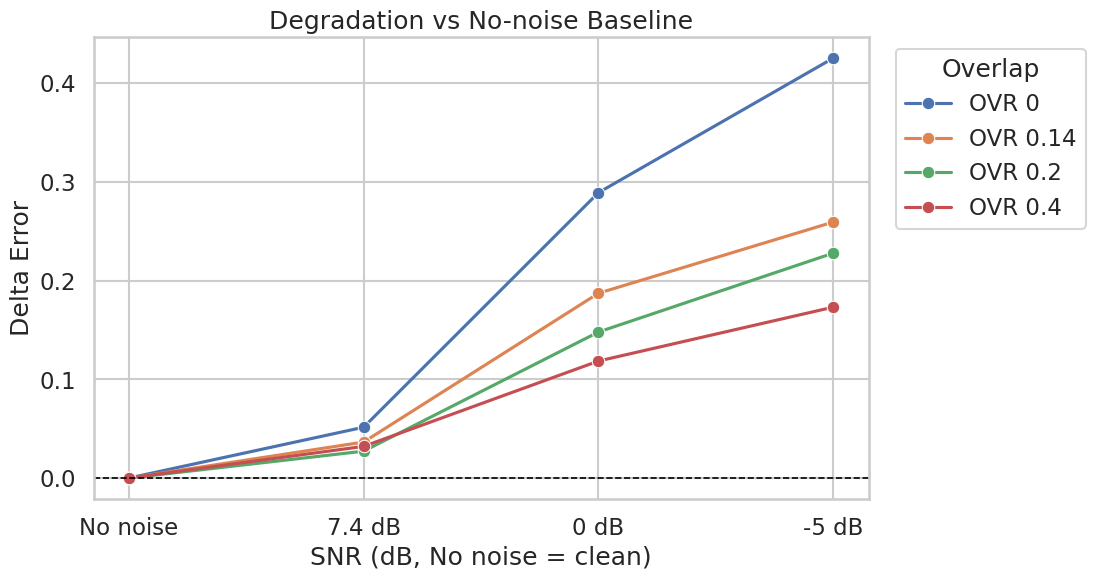

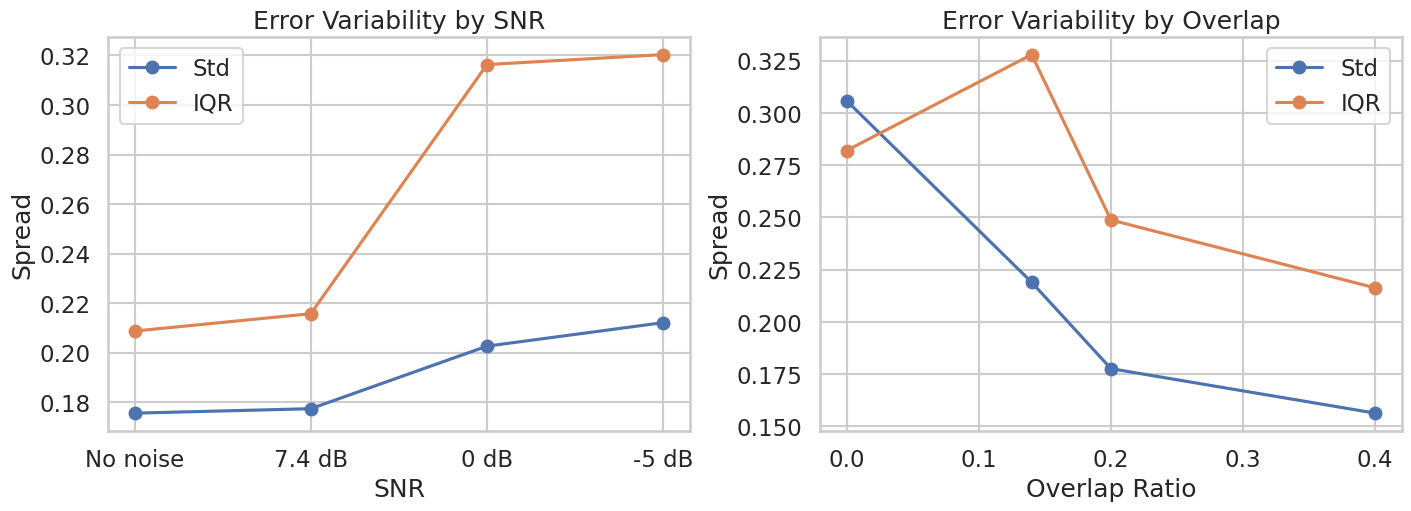

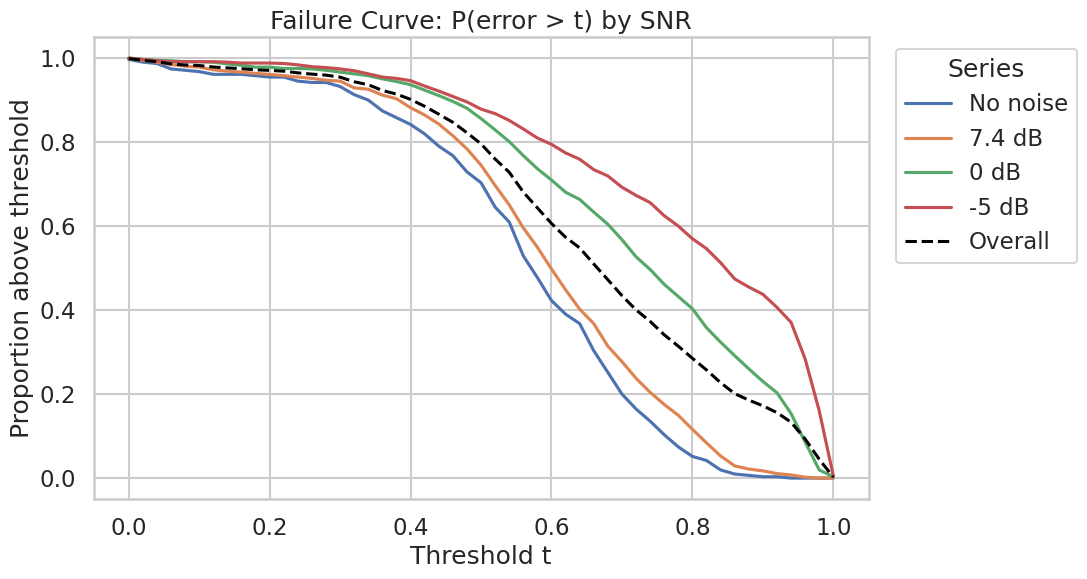

In [4]:
save_plot(plot_error_cdf_by_snr(df_success), "error_cdf_by_snr.png")
plt.show()

save_plot(plot_degradation_delta_vs_snr(df_success), "degradation_delta_vs_snr.png")
plt.show()

save_plot(plot_error_variability_by_condition(df_success), "error_variability_by_condition.png")
plt.show()

## Interpretation Tables, New Insight Plots, and What They Mean

### New insight plots added

1. **Error CDF by SNR**:
Shows the full error distribution per SNR; lower curves are better only at very low thresholds, while higher-left curves indicate stronger robustness across clips.

2. **Degradation vs No-noise baseline**:
Shows $\Delta\text{error}$ relative to No-noise at each overlap level; values above 0 indicate degradation introduced by noise.

3. **Variability by condition (Std and IQR)**:
Shows stability, not just mean performance; high spread indicates unpredictable behavior under that condition.

### Interpretation Tables


SNR-level error statistics:


,snr_db,count,mean,median,std,min,max,snr_label
0,-5.0,930,0.785171,0.846536,0.212158,0.004831,1.080000,-5 dB
1,0.0,930,0.714142,0.738182,0.202674,0.004831,1.013953,0 dB
2,7.4,930,0.591069,0.600000,0.177420,0.000000,0.973214,7.4 dB
3,NaN,930,0.558497,0.572371,0.175623,0.000000,0.930041,No noise



Cross mean error heatmap (SNR x overlap):


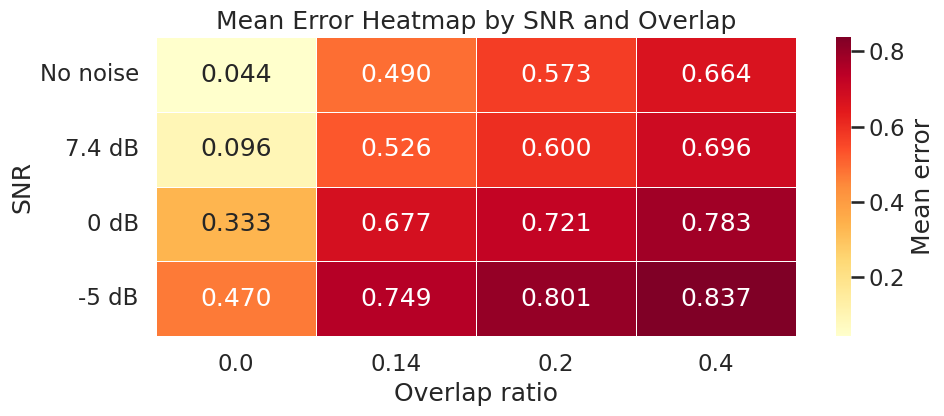

In [17]:
tables = get_interpretation_tables(df_all)

print("\nSNR-level error statistics:")
display(
    tables["snr_stats"]
    .sort_values(["snr_label"])
)

cross_mean = tables["cross_mean"]

print("\nCross mean error heatmap (SNR x overlap):")
save_plot(plot_snr_ovr_heatmap(cross_mean), "wav2_cross_heatmaps.png")
plt.show()

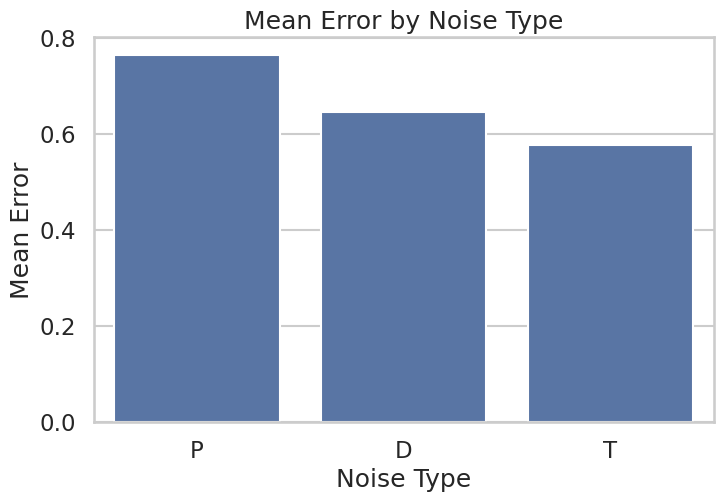

In [6]:
# Extra plot: which noise categories are hardest for wav2vec2
save_plot(plot_noise_type_effect(df_success), "noise_type_effect.png")
plt.show()